#**[ГИТХАБ](https://github.com/Torentine/colab-timeseries-notebooks)**

# Прогноз потребления электроэнергии

Ноутбук подготовлен для Google Colab и GitHub. Он показывает все результаты внутри ячеек и не создает папки с артефактами.


## Запуск в Google Colab

Сначала выполните ячейку ниже, затем запускайте ноутбук сверху вниз.


In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip -q install pandas numpy matplotlib scikit-learn statsmodels

print("Среда готова.")


Среда готова.


## Импорты и загрузка данных


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

LOCAL_PREPARED = Path("data/electricity_daily_prepared.csv")
RAW_URL = "https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/Electricity%20Consumption%20and%20Production%20Data/Electricity.csv"
RANDOM_STATE = 42


def prepare_daily(raw):
    df = raw.copy()
    df["DateTime"] = pd.to_datetime(df["DateTime"])
    numeric_cols = [col for col in df.columns if col != "DateTime"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
    df = df.sort_values("DateTime").drop_duplicates("DateTime")
    hourly = df.set_index("DateTime").asfreq("h")
    hourly[numeric_cols] = hourly[numeric_cols].interpolate(limit_direction="both")
    daily = hourly.resample("D").mean().reset_index()
    daily = daily.rename(columns={"DateTime": "ds", "Consumption": "y"})
    return daily[["ds", "y"]].dropna().reset_index(drop=True)


def load_electricity():
    if LOCAL_PREPARED.exists():
        df = pd.read_csv(LOCAL_PREPARED)
        source = str(LOCAL_PREPARED)
    else:
        raw = pd.read_csv(RAW_URL)
        df = prepare_daily(raw)
        source = RAW_URL
    df["ds"] = pd.to_datetime(df["ds"])
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    return df.dropna().sort_values("ds").reset_index(drop=True), source


daily_df, source = load_electricity()
print(f"Источник данных: {source}")
print(f"Размер ряда: {daily_df.shape[0]} дней")
display(daily_df.head())


Источник данных: https://raw.githubusercontent.com/MVRonkin/TimeSeriesCourse/main/OLD%20Versions/2026/datasets/Electricity%20Consumption%20and%20Production%20Data/Electricity.csv
Размер ряда: 1917 дней


,ds,y
0,2019-01-01,5957.666667
1,2019-01-02,6322.041667
2,2019-01-03,7254.083333
3,2019-01-04,7635.083333
4,2019-01-05,7379.750000


## Проверка качества и EDA


,metric,value
0,start,2019-01-01 00:00:00
1,end,2024-03-31 00:00:00
2,rows,1917
3,missing_y,0
4,duplicate_dates,0
5,frequency_mode,1 days 00:00:00


,daily_consumption
count,1917.000000
mean,6587.756032
std,752.830571
min,4378.083333
25%,6063.541667
50%,6606.791667
75%,7083.333333
max,8728.291667


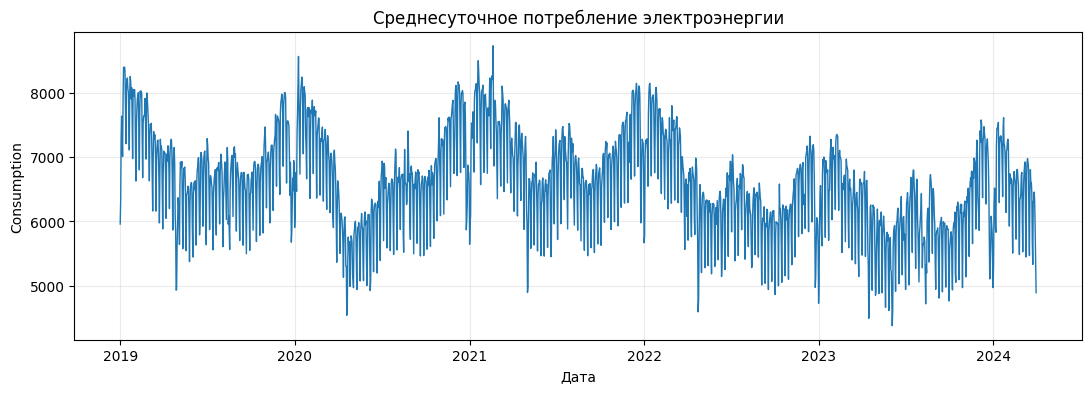

In [3]:
quality = pd.DataFrame({
    "metric": ["start", "end", "rows", "missing_y", "duplicate_dates", "frequency_mode"],
    "value": [
        daily_df["ds"].min(),
        daily_df["ds"].max(),
        len(daily_df),
        int(daily_df["y"].isna().sum()),
        int(daily_df["ds"].duplicated().sum()),
        daily_df["ds"].diff().mode().iloc[0],
    ],
})
display(quality)
display(daily_df["y"].describe().to_frame("daily_consumption"))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_df["ds"], daily_df["y"], linewidth=1)
ax.set_title("Среднесуточное потребление электроэнергии")
ax.set_xlabel("Дата")
ax.set_ylabel("Consumption")
ax.grid(alpha=0.25)
plt.show()


Месячная сезонность


,count,mean,std,min,max
month,,,,,
1,186,7239.079,790.031,4726.542,8561.875
2,170,7165.423,630.172,5484.458,8728.292
3,186,6777.523,642.407,4891.146,8100.625
4,150,6300.158,726.065,4493.333,7537.792
5,155,5988.723,531.957,4615.458,6928.417
6,150,6150.920,578.820,4378.083,7421.458
7,155,6487.789,547.722,4941.583,7519.000
8,155,6353.123,522.580,4718.292,7403.458
9,150,6163.162,515.386,4807.708,6914.708


Недельная сезонность


,count,mean,std,min,max
dayofweek,,,,,
0,273,6637.362,726.059,4605.625,8274.583
1,274,6845.635,664.727,5131.583,8495.625
2,274,6875.604,636.578,5654.750,8333.667
3,274,6875.099,635.954,5251.167,8561.875
4,274,6814.833,646.908,5176.542,8728.292
5,274,6298.403,612.225,4875.792,7781.250
6,274,5767.537,601.120,4378.083,7217.167


Годовая статистика


,count,mean,std,min,max
year,,,,,
2019,365,6859.647,658.692,4930.042,8397.292
2020,366,6622.653,786.270,4540.333,8561.875
2021,365,6956.667,676.255,4894.625,8728.292
2022,365,6426.076,688.762,4593.542,8143.500
2023,365,6088.117,644.742,4378.083,7574.792
2024,91,6529.700,612.775,4891.146,7609.958


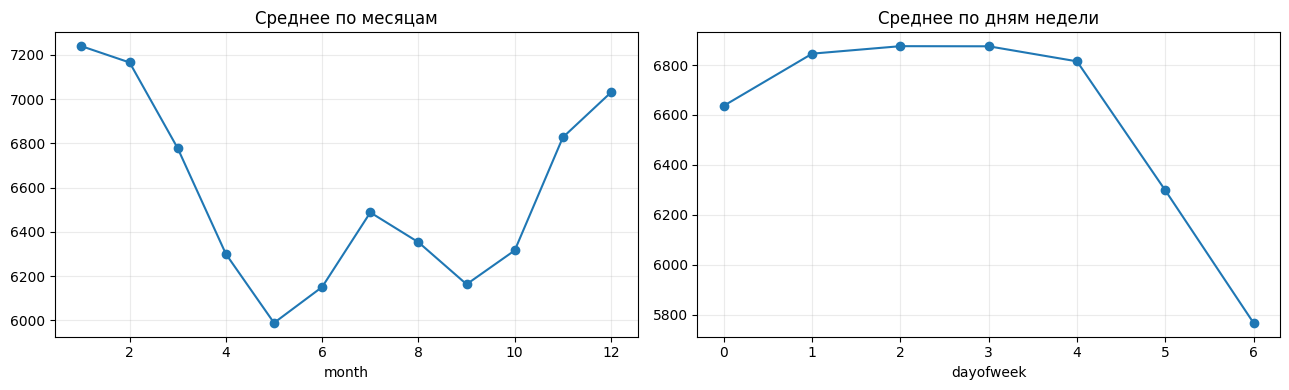

In [4]:
eda = daily_df.copy()
eda["year"] = eda["ds"].dt.year
eda["month"] = eda["ds"].dt.month
eda["dayofweek"] = eda["ds"].dt.dayofweek

monthly = eda.groupby("month")["y"].agg(["count", "mean", "std", "min", "max"]).round(3)
weekly = eda.groupby("dayofweek")["y"].agg(["count", "mean", "std", "min", "max"]).round(3)
yearly = eda.groupby("year")["y"].agg(["count", "mean", "std", "min", "max"]).round(3)

print("Месячная сезонность")
display(monthly)
print("Недельная сезонность")
display(weekly)
print("Годовая статистика")
display(yearly)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly["mean"].plot(ax=axes[0], marker="o", title="Среднее по месяцам")
weekly["mean"].plot(ax=axes[1], marker="o", title="Среднее по дням недели")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Сравнение моделей прогноза


,group,model,MAE,RMSE,MAPE_%
0,Statistical,ExpSmoothing,241.9129,301.8193,4.3635
1,Baseline,SeasonalNaive_7,329.6339,367.0880,5.7116
2,Baseline,MovingAverage_14,481.3202,718.2709,9.0960
3,ML,Ridge_alpha_25,482.8924,611.0807,8.3120
4,ML,LinearRegression,483.6287,610.9795,8.3207
5,ML,KNN_15,623.4159,724.5695,11.0338
6,DL,MLP_medium,685.4431,859.3557,12.1161
7,Baseline,Naive,732.2887,816.4613,11.9470
8,DL,MLP_small,2279.2470,3183.4736,36.7411


,ds,actual,Naive,SeasonalNaive_7,MovingAverage_14,ExpSmoothing,LinearRegression,Ridge_alpha_25,KNN_15,MLP_small,MLP_medium
0,2024-03-25,6313.3750,5329.625,6403.2500,6403.2857,6206.9882,5183.7218,5184.8266,5325.6458,665.9176,4803.4625
1,2024-03-26,6311.8750,5329.625,6803.2917,6403.2857,6428.4698,6147.4483,6145.9675,6421.5056,516.7727,6050.9361
2,2024-03-27,6454.6250,5329.625,6589.3750,6403.2857,6459.3242,5812.9413,5817.8007,6093.6194,4585.3686,6429.7837
3,2024-03-28,6304.1250,5329.625,6602.1250,6403.2857,6432.9762,6191.2557,6192.6622,6541.7861,5572.3450,6468.9211
4,2024-03-29,5898.2083,5329.625,6446.1667,6403.2857,6356.4364,5891.1135,5897.4679,6496.0389,4979.7868,6622.8757
5,2024-03-30,5383.0833,5329.625,5690.0417,6403.2857,5831.3040,6073.9582,6077.4702,6435.5444,5657.3090,6304.7688
6,2024-03-31,4891.1458,5329.625,5329.6250,6403.2857,5321.5554,5529.9442,5533.5226,5908.7389,5609.6315,6082.4053


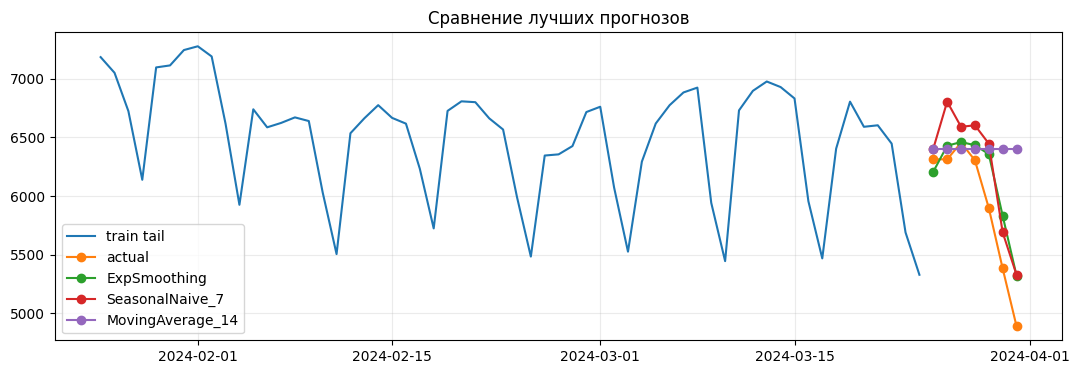

In [5]:
HORIZON = 7
train = daily_df.iloc[:-HORIZON].copy()
test = daily_df.iloc[-HORIZON:].copy()


def make_features(data):
    out = data.copy()
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out["y"].shift(lag)
    for window in [7, 14, 28]:
        out[f"roll_mean_{window}"] = out["y"].shift(1).rolling(window).mean()
        out[f"roll_std_{window}"] = out["y"].shift(1).rolling(window).std()
    out["dayofweek"] = out["ds"].dt.dayofweek
    out["month"] = out["ds"].dt.month
    return out.dropna().reset_index(drop=True)


FEATURES = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_std_7", "roll_mean_14", "roll_std_14",
    "roll_mean_28", "roll_std_28", "dayofweek", "month",
]


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_%": np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100,
    }


def recursive_forecast(model, history, horizon, scaler=None):
    hist = history.copy().reset_index(drop=True)
    preds = []
    for _ in range(horizon):
        row = pd.DataFrame({"ds": [hist["ds"].iloc[-1] + pd.Timedelta(days=1)], "y": [np.nan]})
        candidate = pd.concat([hist, row], ignore_index=True)
        feats = make_features(candidate).tail(1)
        x = feats[FEATURES].to_numpy()
        if scaler is not None:
            x = scaler.transform(x)
        pred = float(model.predict(x)[0])
        preds.append(pred)
        hist.loc[len(hist)] = {"ds": row["ds"].iloc[0], "y": pred}
    return np.array(preds)


feature_train = make_features(train)
X_train = feature_train[FEATURES].to_numpy()
y_train = feature_train["y"].to_numpy()
y_test = test["y"].to_numpy()

results = []
forecast_table = test[["ds", "y"]].rename(columns={"y": "actual"}).reset_index(drop=True)

baselines = {
    "Naive": np.repeat(train["y"].iloc[-1], HORIZON),
    "SeasonalNaive_7": train["y"].iloc[-7:].to_numpy(),
    "MovingAverage_14": np.repeat(train["y"].tail(14).mean(), HORIZON),
}
for name, pred in baselines.items():
    results.append({"group": "Baseline", "model": name, **metrics(y_test, pred)})
    forecast_table[name] = pred

try:
    exp_model = ExponentialSmoothing(train["y"], trend="add", seasonal="add", seasonal_periods=7).fit()
    exp_pred = exp_model.forecast(HORIZON).to_numpy()
    results.append({"group": "Statistical", "model": "ExpSmoothing", **metrics(y_test, exp_pred)})
    forecast_table["ExpSmoothing"] = exp_pred
except Exception as exc:
    print(f"ExpSmoothing пропущен: {exc}")

for name, model, group, use_scaler in [
    ("LinearRegression", LinearRegression(), "ML", False),
    ("Ridge_alpha_25", Ridge(alpha=25.0), "ML", False),
    ("KNN_15", KNeighborsRegressor(n_neighbors=15), "ML", True),
    ("MLP_small", MLPRegressor(hidden_layer_sizes=(16,), max_iter=400, random_state=RANDOM_STATE), "DL", True),
    ("MLP_medium", MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=400, random_state=RANDOM_STATE), "DL", True),
]:
    scaler = StandardScaler() if use_scaler else None
    X_fit = scaler.fit_transform(X_train) if scaler else X_train
    model.fit(X_fit, y_train)
    pred = recursive_forecast(model, train, HORIZON, scaler=scaler)
    results.append({"group": group, "model": name, **metrics(y_test, pred)})
    forecast_table[name] = pred

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(results_df.round(4))
display(forecast_table.round(4))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train["ds"].tail(60), train["y"].tail(60), label="train tail")
ax.plot(test["ds"], y_test, marker="o", label="actual")
for col in results_df["model"].head(3):
    ax.plot(forecast_table["ds"], forecast_table[col], marker="o", label=col)
ax.set_title("Сравнение лучших прогнозов")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Анализ аномалий


,method,anomalies
0,Seasonal_IQR,296
1,Rolling_Z,3
2,IsolationForest,38


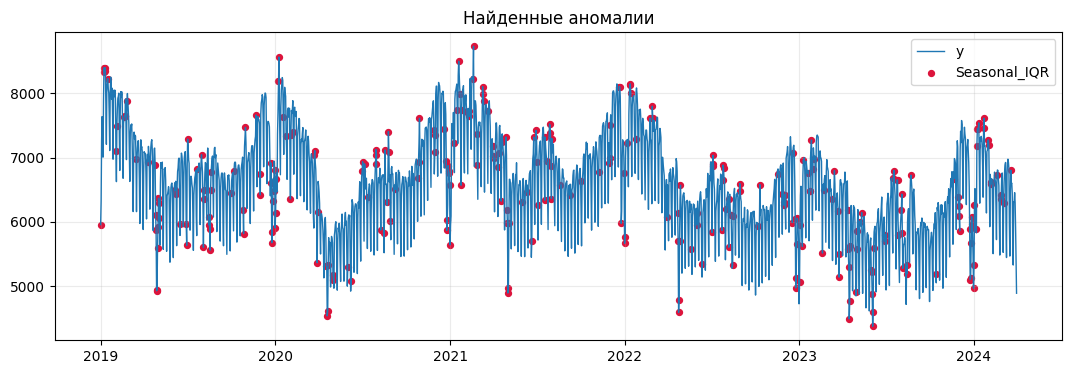

In [6]:
anom = daily_df.copy()
stl = STL(anom["y"], period=7, robust=True).fit()
anom["residual"] = stl.resid
q1, q3 = anom["residual"].quantile([0.25, 0.75])
iqr = q3 - q1
anom["Seasonal_IQR"] = (anom["residual"] < q1 - 1.5 * iqr) | (anom["residual"] > q3 + 1.5 * iqr)

rolling_mean = anom["y"].rolling(30, min_periods=14).mean()
rolling_std = anom["y"].rolling(30, min_periods=14).std()
z = (anom["y"] - rolling_mean) / rolling_std
anom["Rolling_Z"] = z.abs() > 3

iso_features = make_features(anom)[FEATURES]
iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)
iso_pred = iso.fit_predict(iso_features)
anom["IsolationForest"] = False
anom.loc[iso_features.index, "IsolationForest"] = iso_pred == -1

summary = pd.DataFrame({
    "method": ["Seasonal_IQR", "Rolling_Z", "IsolationForest"],
    "anomalies": [int(anom["Seasonal_IQR"].sum()), int(anom["Rolling_Z"].sum()), int(anom["IsolationForest"].sum())],
})
display(summary)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(anom["ds"], anom["y"], linewidth=1, label="y")
points = anom[anom["Seasonal_IQR"]]
ax.scatter(points["ds"], points["y"], color="crimson", s=18, label="Seasonal_IQR")
ax.set_title("Найденные аномалии")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## Итог

Ноутбук показывает полный цикл анализа: подготовка дневного ряда, EDA, сравнение моделей прогноза и поиск аномалий. Все результаты остаются внутри ноутбука.
